In [ ]:
# Характеристика 

# Исследование нелинейного МНК

In [1]:
from testing import testing
import numpy as np
import matplotlib.pyplot as plt

## Иследование на количество итераций

Зависимотсть среднего критерия от числа итераций алгоритма. 

Бесшумные данные. 45 поворотов.

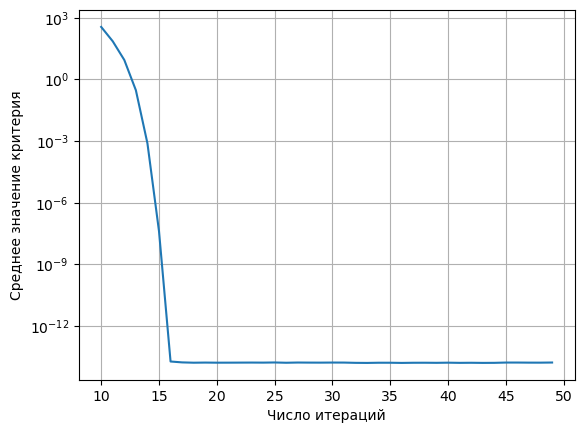

33


In [ ]:
iter_num = 50
model_num = 500

x = range(10, iter_num)
y = []

for i in x:
    res = 0
    for j in range(model_num):
        crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 1500, 0], func_params=[i])
        res += crit
    res /= model_num
    y.append(res)

plt.plot(x, y)
plt.xlabel('Число итераций')
plt.ylabel('Среднее значение критерия')
plt.yscale('log')
plt.grid()
plt.show()

print(x[np.argmin(y)])

Зашумленные данные

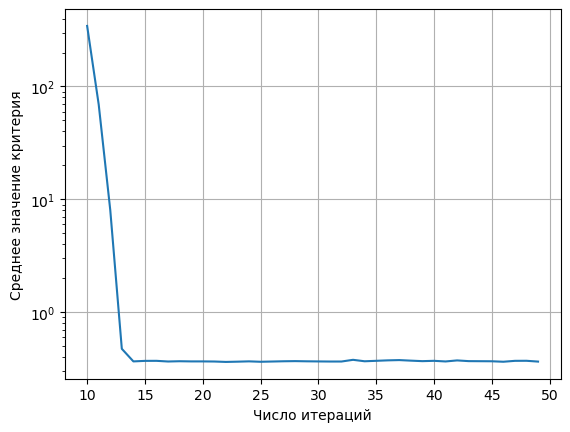

22


In [ ]:
iter_num = 50
model_num = 500

x = range(10, iter_num)
y = []

for i in x:
    res = 0
    for j in range(model_num):
        crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[i])
        res += crit
    res /= model_num
    y.append(res)

plt.plot(x, y)
plt.xlabel('Число итераций')
plt.ylabel('Среднее значение критерия')
plt.yscale('log')
plt.grid()
plt.show()

print(x[np.argmin(y)])

## Исследование стабильности критерия

Интервальный ряд критериев. Его статистические параметры.

Бесшумные данные. 45 поворотов. 30 итераций.

0
Выборочное мат. ожидание:  1.6011527906003824e-14
Выборочное СКО:  5.115256529873448e-15


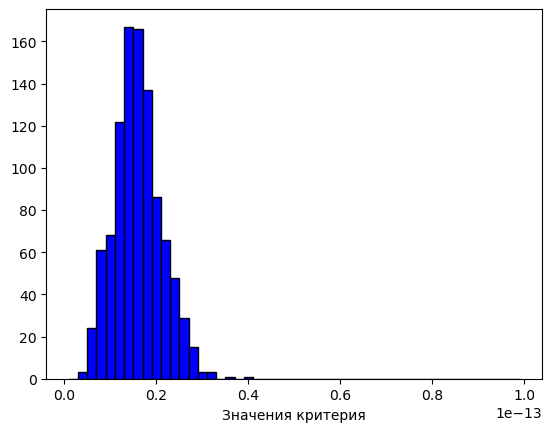

In [ ]:
res = []
deads = 0
for j in range(1000):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 0], func_params=[20])
    if crit > 1e-13:
        deads += 1
        continue
    res.append(crit)

print(deads)

plt.hist(res, color='blue', edgecolor='black', bins=np.arange(1e-15, 1e-13, 2e-15))
# plt.xscale('log')
plt.xlabel('Значения критерия')

print('Выборочное мат. ожидание: ', np.mean(res))
print('Выборочное СКО: ', np.std(res))

Зашумленные данные

0
Выборочное мат. ожидание:  0.36940570025484387
Выборочное СКО:  0.07704852238209217


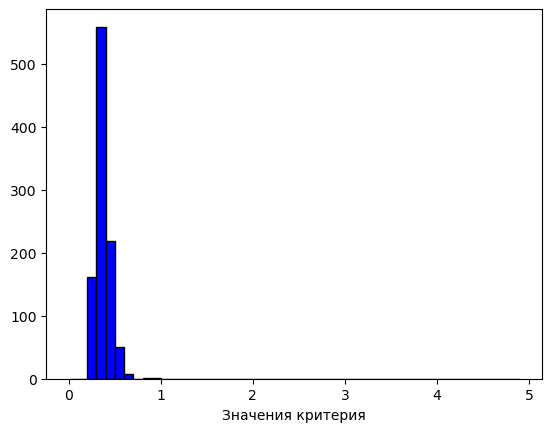

In [ ]:
res = []
deads = 0
for j in range(1000):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[20])
    # if crit > 1e-13:
    #     deads += 1
    #     continue
    res.append(crit)

print(deads)

plt.hist(res, color='blue', edgecolor='black', bins=np.arange(0, 5, 0.1))
# plt.xscale('log')
plt.xlabel('Значения критерия')

print('Выборочное мат. ожидание: ', np.mean(res))
print('Выборочное СКО: ', np.std(res))

## Исследование относительной ошибки коэффициентов

Безшумные данные

2 0.002


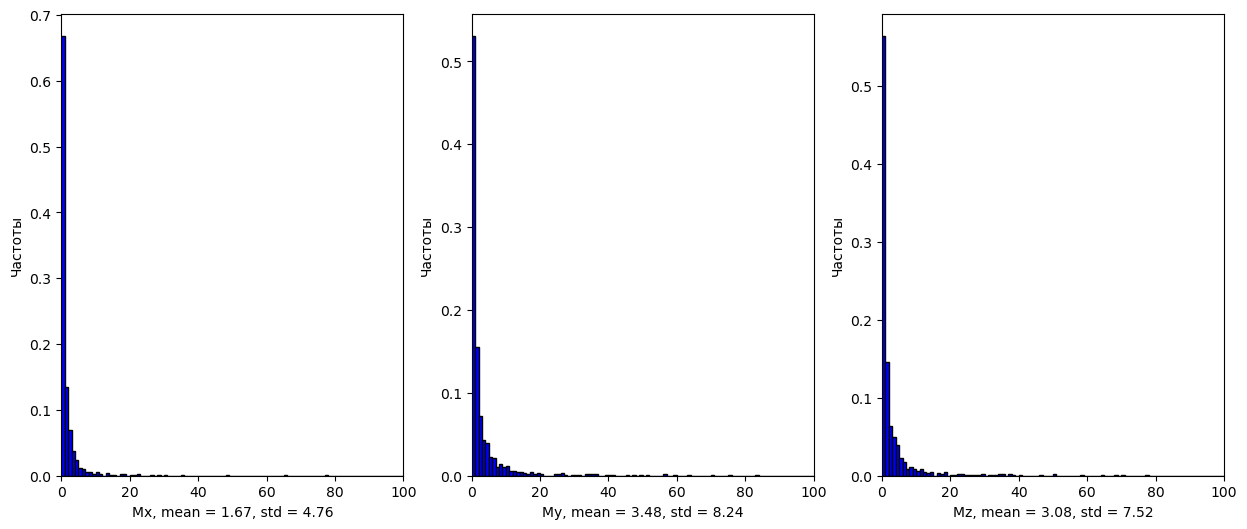

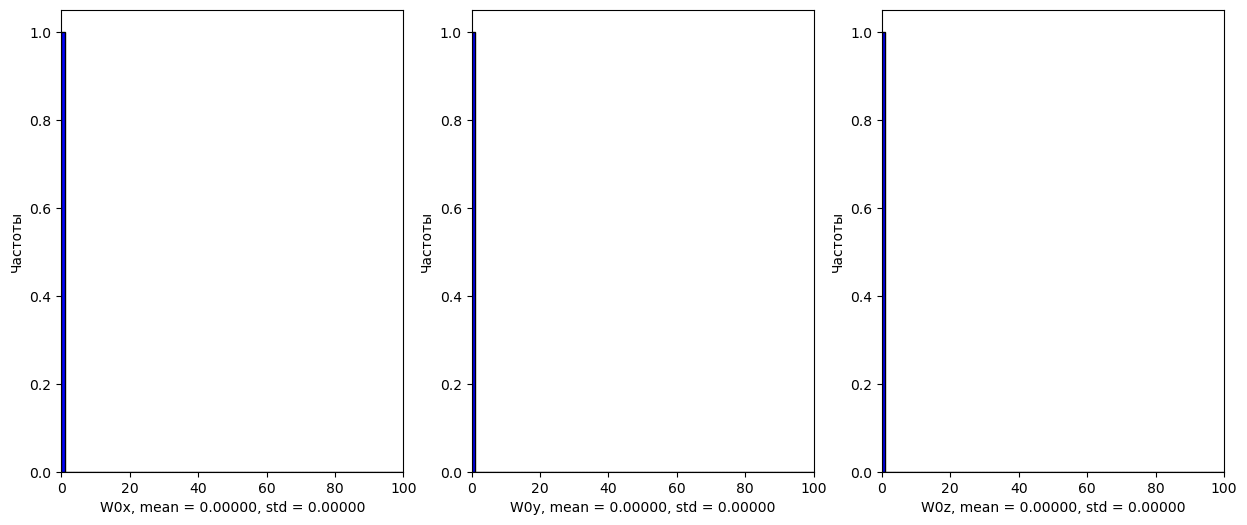

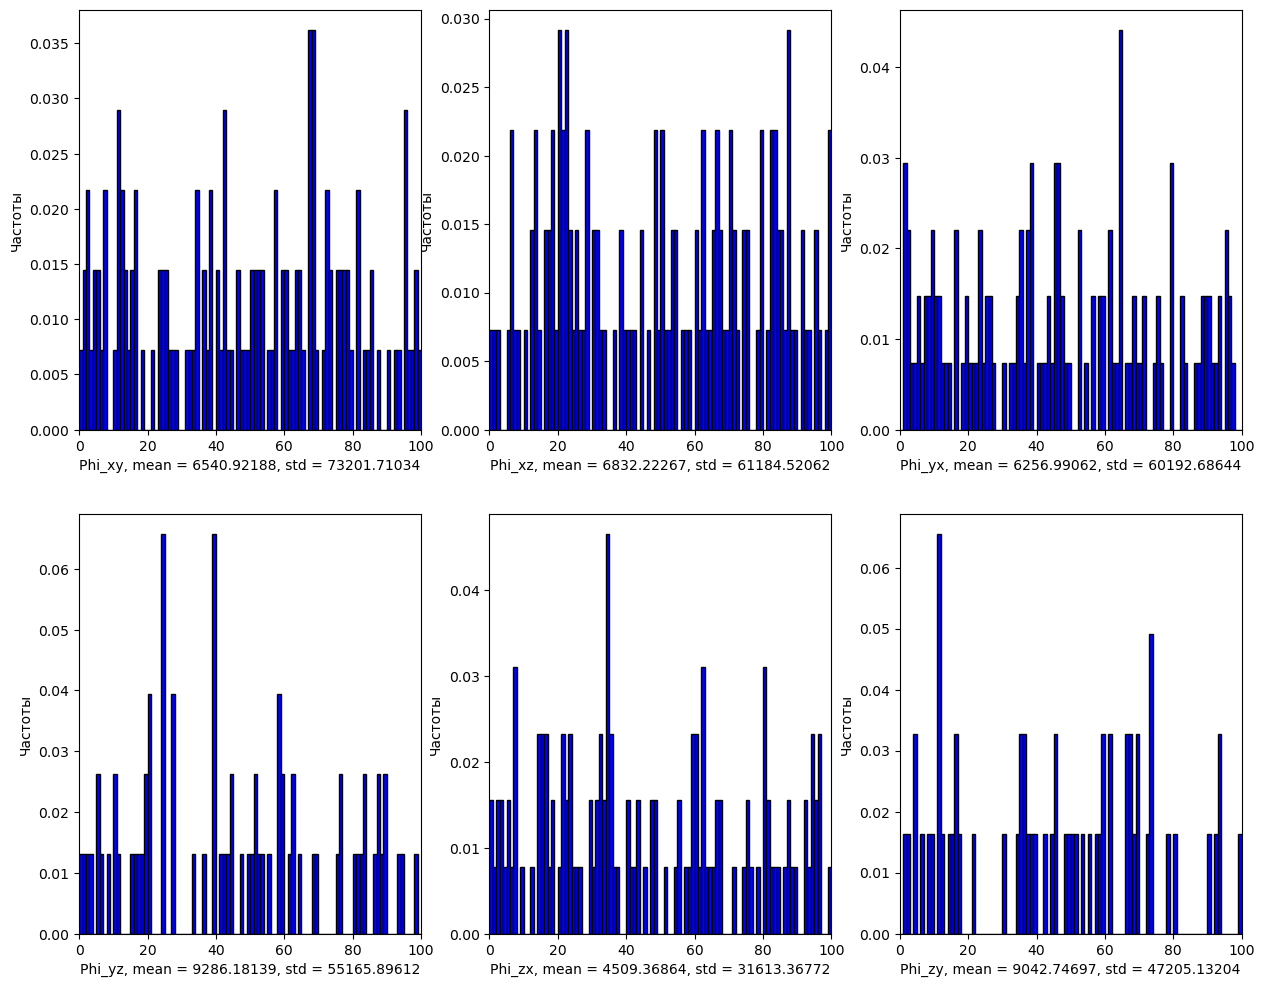

In [9]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 0], func_params=[20])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(rel[0])
    res['My'].append(rel[1])
    res['Mz'].append(rel[2])
    res['Phi_xy'].append(rel[3])
    res['Phi_xz'].append(rel[4])
    res['Phi_yx'].append(rel[5])
    res['Phi_yz'].append(rel[6])
    res['Phi_zx'].append(rel[7])
    res['Phi_zy'].append(rel[8])
    res['W0x'].append(rel[9])
    res['W0y'].append(rel[10])
    res['W0z'].append(rel[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')

plt.figure(3, figsize=(15, 12))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+6]}, mean = {np.mean(res[axis_name[i+6]]):.5f}, std = {np.std(res[axis_name[i+6]]):.5f}')
    plt.ylabel('Частоты')

Зашумленные данные

30 0.03


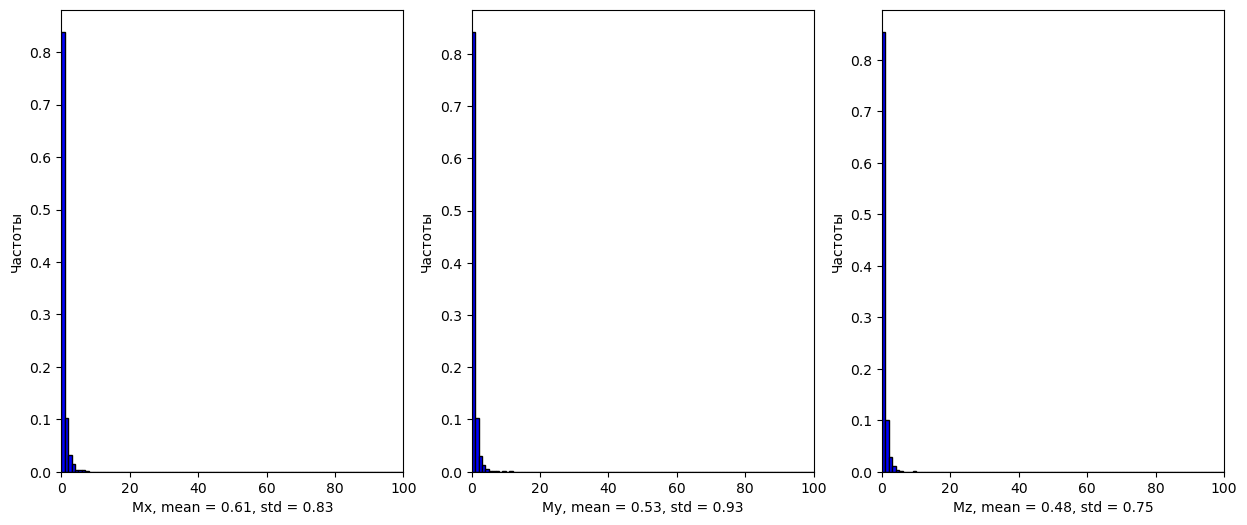

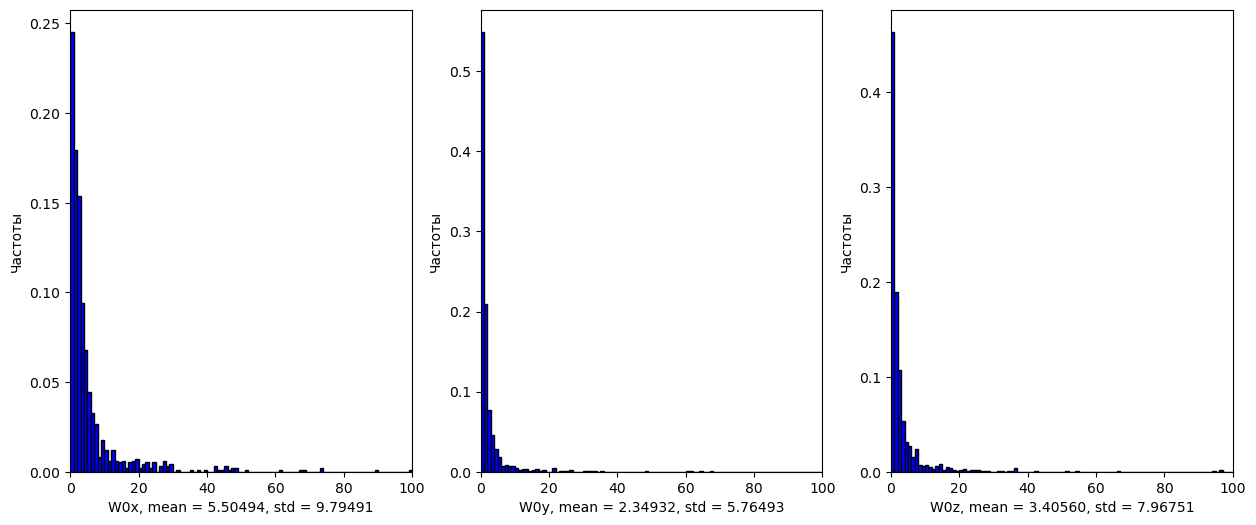

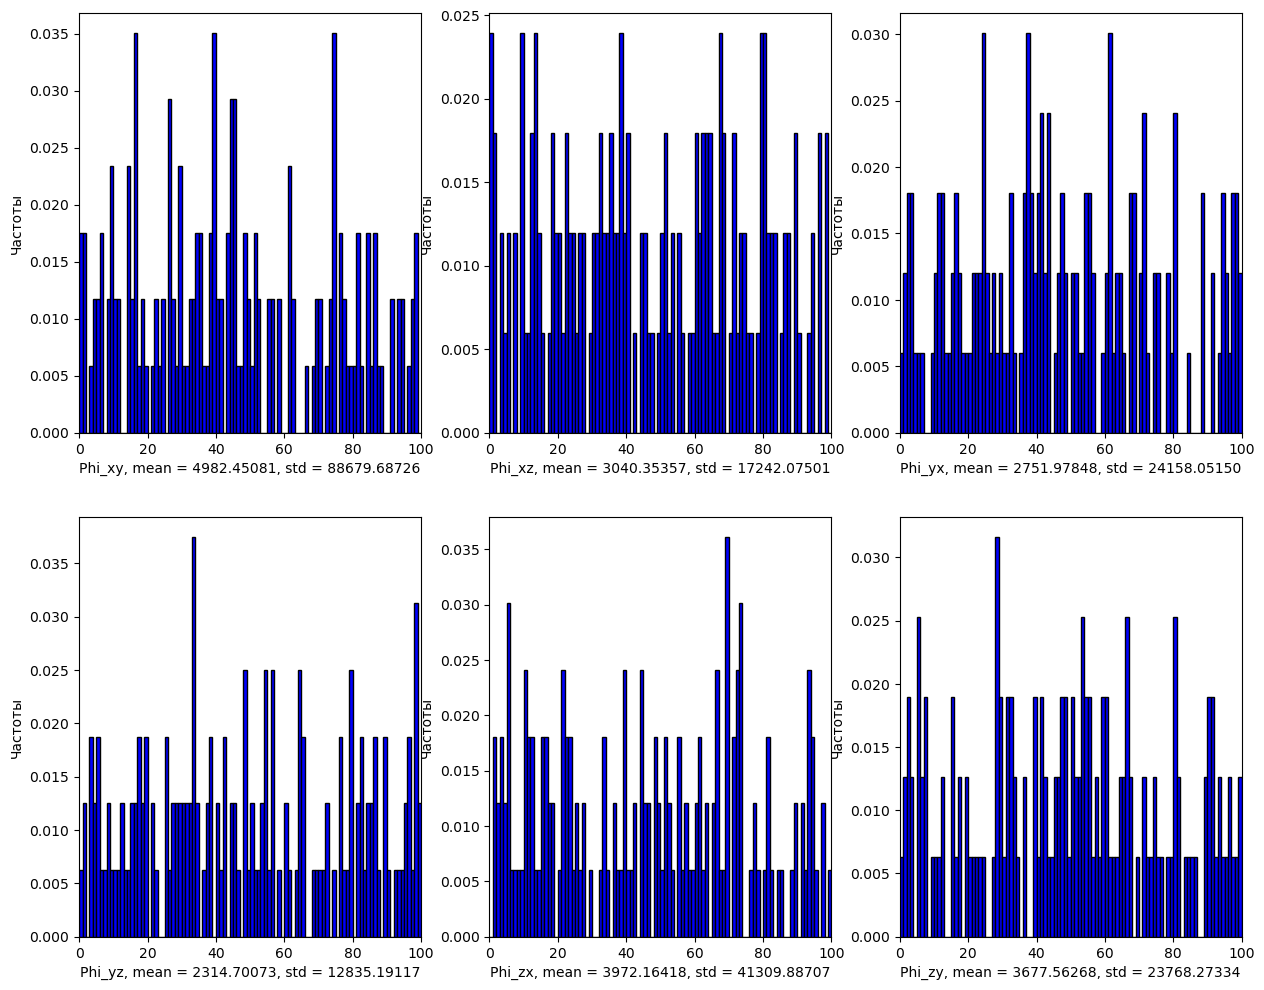

In [ ]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 1000, 50], func_params=[20])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(rel[0])
    res['My'].append(rel[1])
    res['Mz'].append(rel[2])
    res['Phi_xy'].append(rel[3])
    res['Phi_xz'].append(rel[4])
    res['Phi_yx'].append(rel[5])
    res['Phi_yz'].append(rel[6])
    res['Phi_zx'].append(rel[7])
    res['Phi_zy'].append(rel[8])
    res['W0x'].append(rel[9])
    res['W0y'].append(rel[10])
    res['W0z'].append(rel[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')

plt.figure(3, figsize=(15, 12))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+6]}, mean = {np.mean(res[axis_name[i+6]]):.5f}, std = {np.std(res[axis_name[i+6]]):.5f}')
    plt.ylabel('Частоты')

# Исследование распределения асолютных ошибок определения параметров

2 0.002


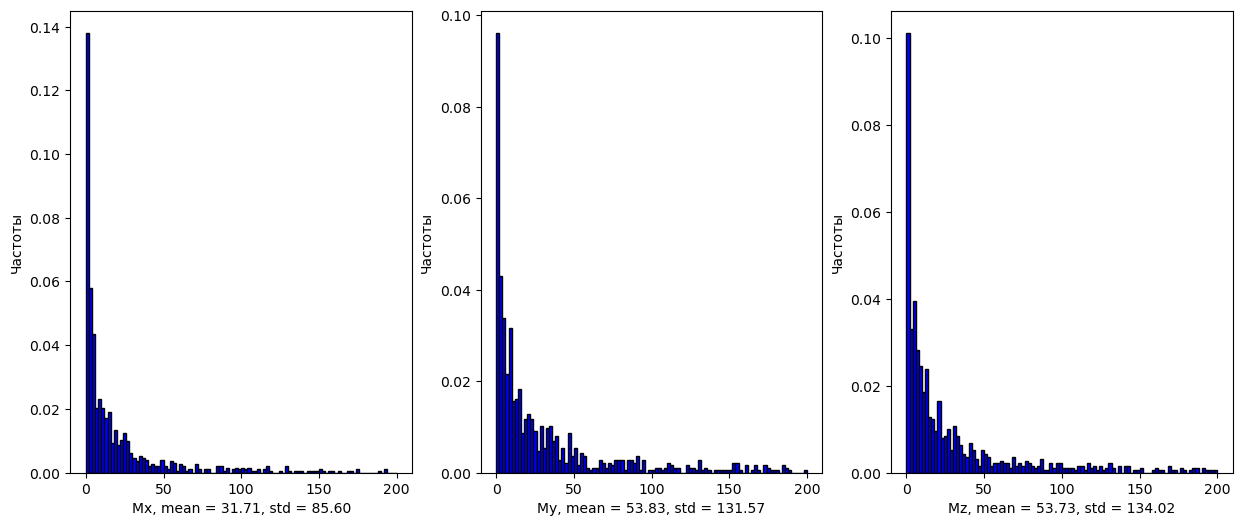

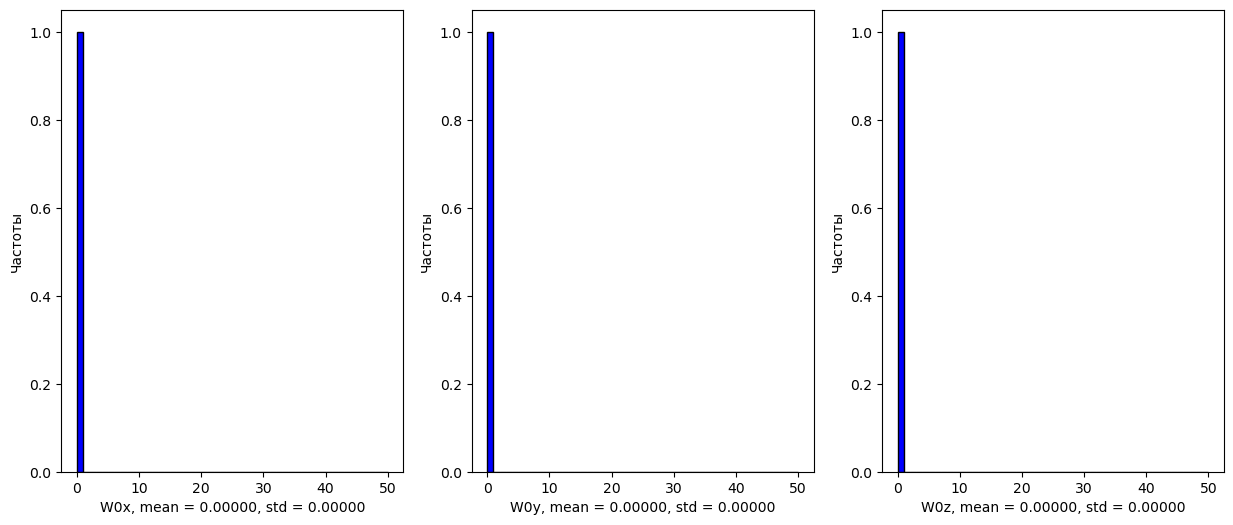

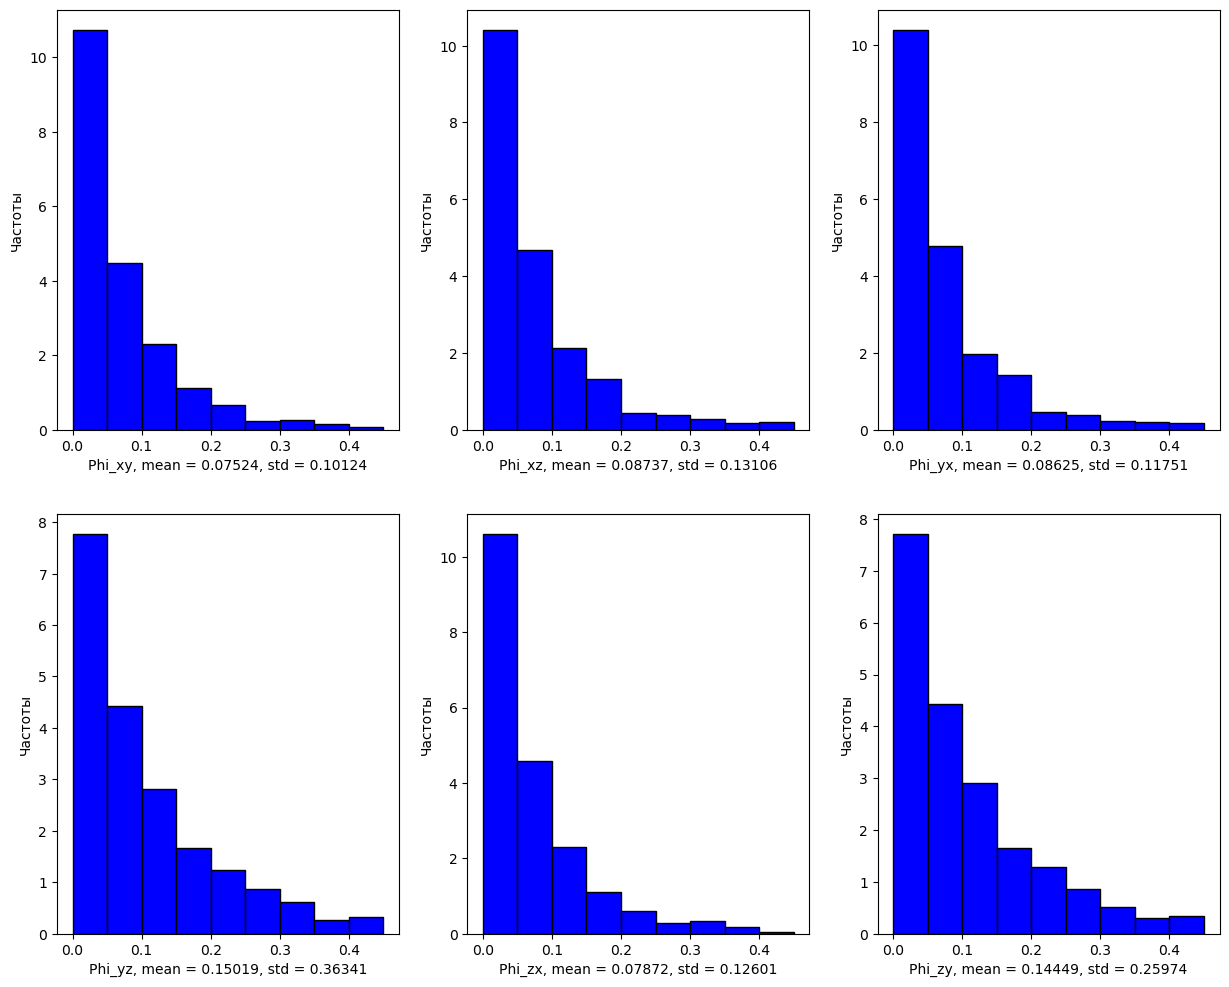

In [6]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 0], func_params=[20])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(abse[0])
    res['My'].append(abse[1])
    res['Mz'].append(abse[2])
    res['Phi_xy'].append(abse[3])
    res['Phi_xz'].append(abse[4])
    res['Phi_yx'].append(abse[5])
    res['Phi_yz'].append(abse[6])
    res['Phi_zx'].append(abse[7])
    res['Phi_zy'].append(abse[8])
    res['W0x'].append(abse[9])
    res['W0y'].append(abse[10])
    res['W0z'].append(abse[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 201, 2)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 51, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')

plt.figure(3, figsize=(15, 12))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 0.5, 0.05)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+6]}, mean = {np.mean(res[axis_name[i+6]]):.5f}, std = {np.std(res[axis_name[i+6]]):.5f}')
    plt.ylabel('Частоты')

Зашумленные данные

27 0.027


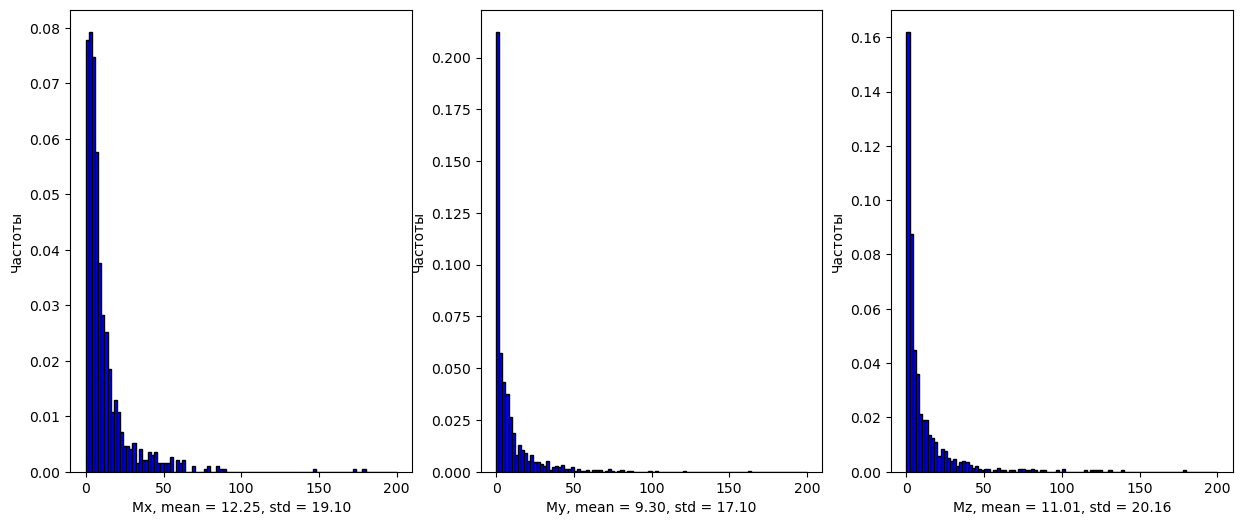

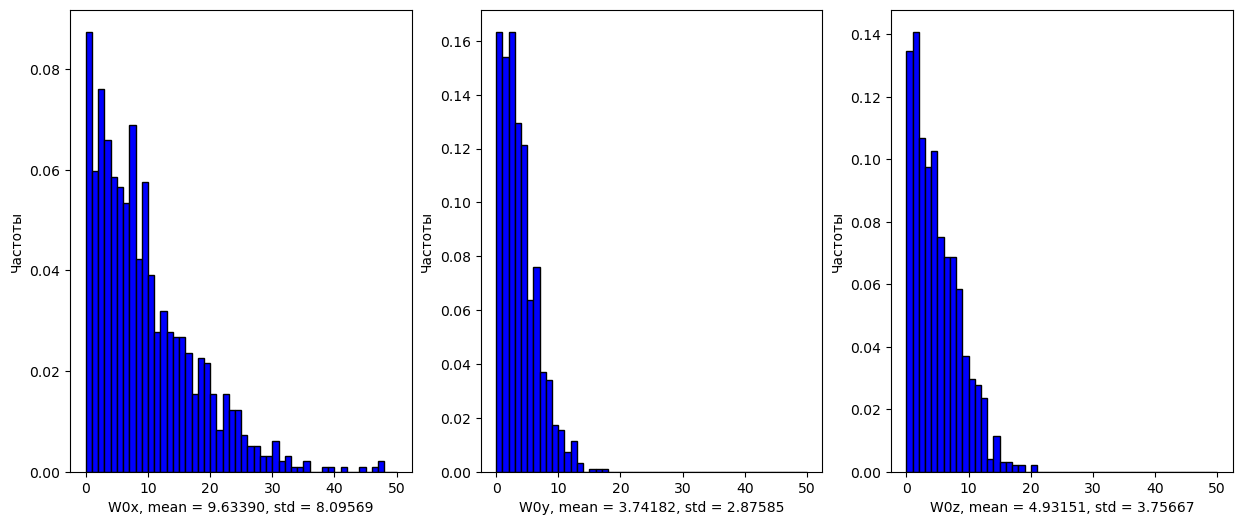

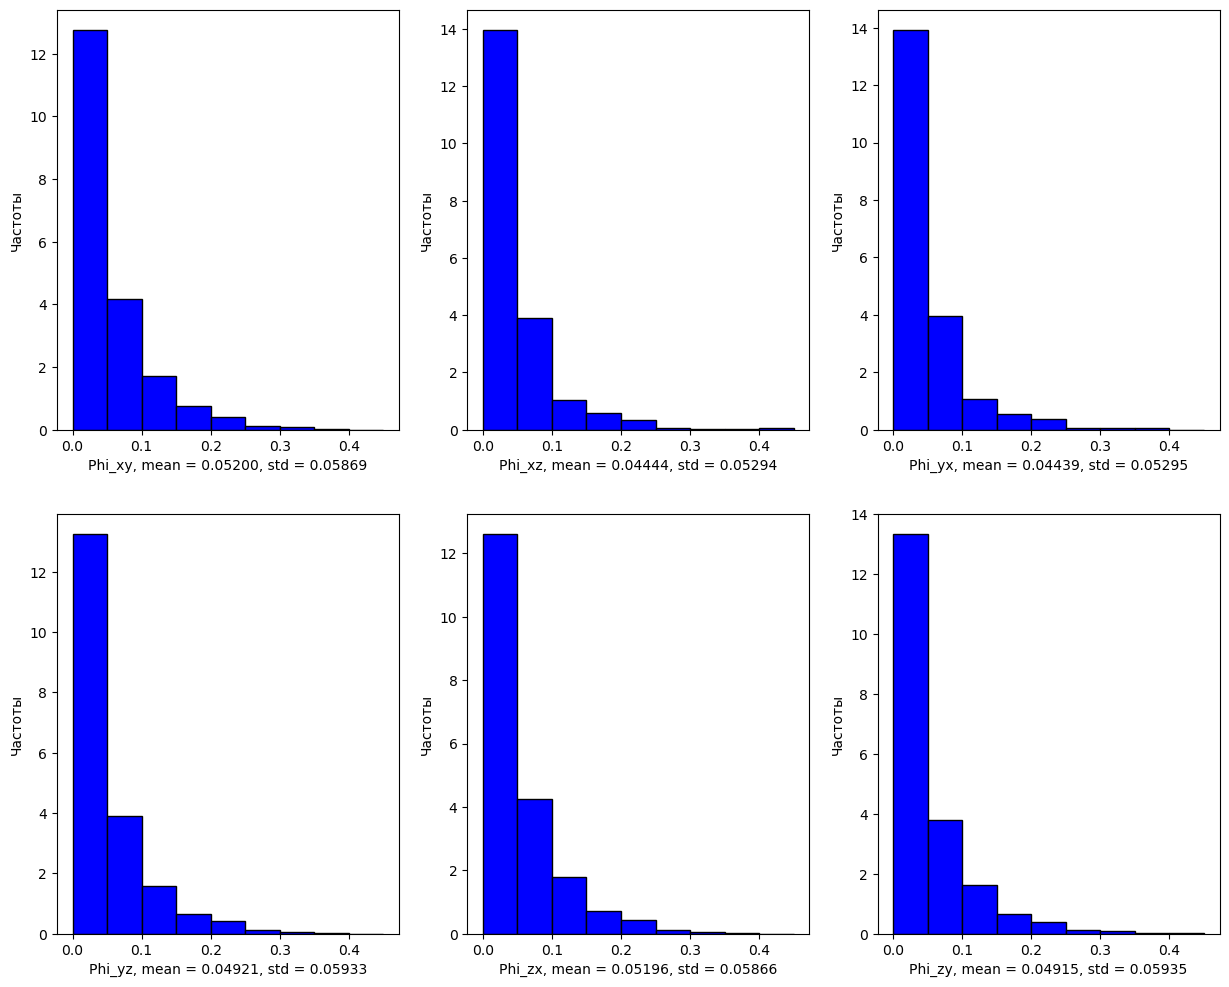

In [7]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[20])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(abse[0])
    res['My'].append(abse[1])
    res['Mz'].append(abse[2])
    res['Phi_xy'].append(abse[3])
    res['Phi_xz'].append(abse[4])
    res['Phi_yx'].append(abse[5])
    res['Phi_yz'].append(abse[6])
    res['Phi_zx'].append(abse[7])
    res['Phi_zy'].append(abse[8])
    res['W0x'].append(abse[9])
    res['W0y'].append(abse[10])
    res['W0z'].append(abse[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 201, 2)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 51, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')

plt.figure(3, figsize=(15, 12))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 0.5, 0.05)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+6]}, mean = {np.mean(res[axis_name[i+6]]):.5f}, std = {np.std(res[axis_name[i+6]]):.5f}')
    plt.ylabel('Частоты')

# Изменение критерия относительно параметра

Зависимость J(M_x)

2369.775266178357


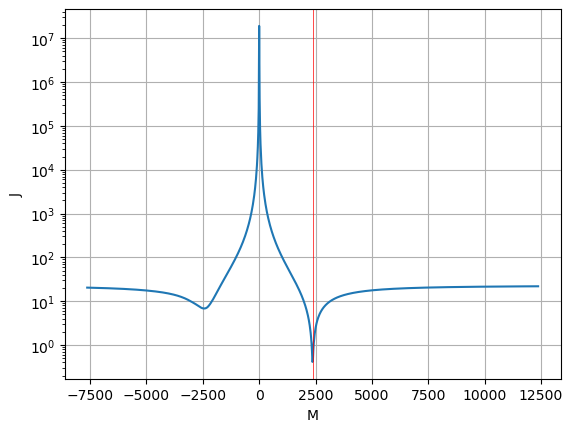

In [ ]:
from utils.model import Imu
from utils.metrics import avg_criteria


m_avg = 2000
w0_sig = 500
phi_sig = 0.1
noise = 0
        
tM = np.abs(np.random.normal(m_avg, 0.2 * m_avg, size=(3, 1)))
tphi = np.random.normal(0, phi_sig, size=(6, 1))
tw0 = np.random.normal(0, w0_sig, size=(3, 1))
params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
# print(params)
imu = Imu(params, noise)
raw_data = imu.generate_rotation(10, 20)

avg = tM[0, 0]
edge = 10000
print(avg)
y = []
x = np.linspace(avg - edge, avg + edge, 1000)
for n in x:
    params = [n, tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
    imu.update(params)
    y.append(avg_criteria(imu.raw_to_acc(raw_data)))

plt.plot(x, y)
plt.axvline(avg, color='red', linewidth=0.5)
plt.yscale('log')
plt.xlabel("M")
plt.ylabel('J')
plt.grid()

Зависимость J(r0)

-272.70108990239123


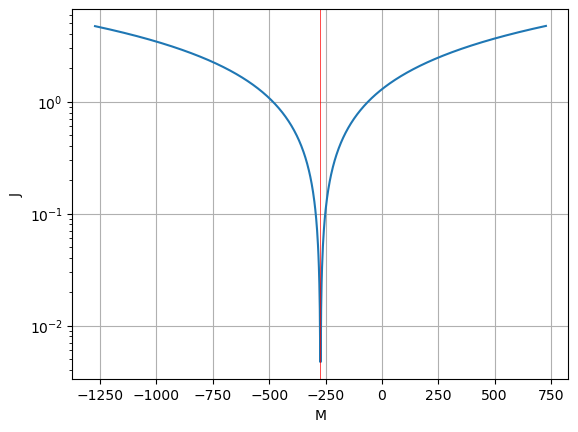

In [22]:
from utils.model import Imu
from utils.metrics import avg_criteria


m_avg = 2000
w0_sig = 500
phi_sig = 0.1
noise = 0
        
tM = np.abs(np.random.normal(m_avg, 0.2 * m_avg, size=(3, 1)))
tphi = np.random.normal(0, phi_sig, size=(6, 1))
tw0 = np.random.normal(0, w0_sig, size=(3, 1))
params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
# print(params)
imu = Imu(params, noise)
raw_data = imu.generate_rotation(10, 20)

avg = tw0[0, 0]
edge = 1000
print(avg)
y = []
x = np.linspace(avg - edge, avg + edge, 1000)
for n in x:
    params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                n, tw0[1, 0], tw0[2, 0]]
    imu.update(params)
    y.append(avg_criteria(imu.raw_to_acc(raw_data)))

plt.plot(x, y)
plt.axvline(avg, color='red', linewidth=0.5)
plt.yscale('log')
plt.xlabel("M")
plt.ylabel('J')
plt.grid()

Зависимость J(phi)

-0.0424194286195433


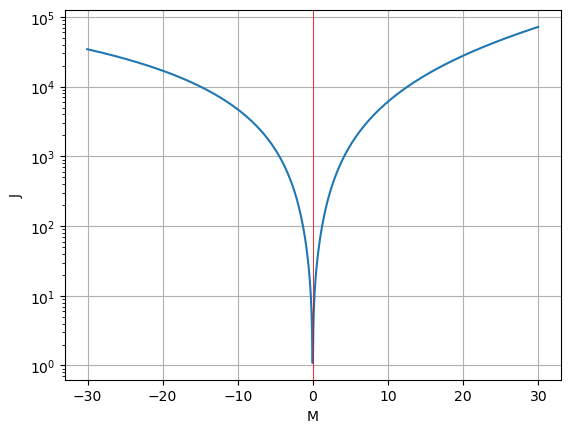

In [5]:
from utils.model import Imu
from utils.metrics import avg_criteria


m_avg = 2000
w0_sig = 500
phi_sig = 0.1
noise = 0
        
tM = np.abs(np.random.normal(m_avg, 0.2 * m_avg, size=(3, 1)))
tphi = np.random.normal(0, phi_sig, size=(6, 1))
tw0 = np.random.normal(0, w0_sig, size=(3, 1))
params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
# print(params)
imu = Imu(params, noise)
raw_data = imu.generate_rotation(10, 20)

avg = tphi[0, 0]
edge = 30
print(avg)
y = []
x = np.linspace(avg - edge, avg + edge, 1000)
for n in x:
    params = [tM[0, 0], tM[1, 0], tM[2, 0], n, tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                tw0[0, 0], tw0[1, 0], tw0[2, 0]]
    imu.update(params)
    y.append(avg_criteria(imu.raw_to_acc(raw_data)))

plt.plot(x, y)
plt.axvline(avg, color='red', linewidth=0.5)
plt.yscale('log')
plt.xlabel("M")
plt.ylabel('J')
plt.grid()